# Phase 4 Model Comparison — MLP vs Transformer vs Strong Spatial Predictor

## Goal

This notebook compares the final memory-reconstruction model family across the same dataset and input modes:

```text
current black-hole image / observation
→ frozen U-Net encoder
→ memory predictor
→ physical histories [NUM_TARGETS, HISTORY_T]
```

Compared models:

1. **Phase 4 MLP** — pooled bottleneck MLP baseline.
2. **Phase 4-T Transformer** — token-based transformer predictor.
3. **Phase 4-S Strong Spatial** — residual spatial mixer + token transformer + attention pooling + temporal decoder.

Compared input modes:

1. `clean`
2. `noisy`
3. `reconstructed`

The purpose is not just to report the best number. The purpose is to answer the thesis-level question:

> Does a stronger spatial predictor change which physical histories are recoverable?

If yes, then previous failures were partly model-capacity / spatial-information-extraction failures.  
If no, then the bottleneck is information identifiability or generator/reconstruction loss.

In [1]:
# ================================================================
# 1. Imports and setup
# ================================================================

import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 1.26.4
Pandas: 2.3.3


In [2]:
# ================================================================
# 2. Configuration
# ================================================================

PROJECT_ROOT = Path("/home/marwa/files/phase1_blackhole_generator")
OUTPUT_DIR = PROJECT_ROOT / "outputs"
DATA_ROOT = PROJECT_ROOT / "data"

# This comparison is designed around your latest stable dataset family.
# Change this only if you intentionally want to compare another dataset branch.
DATASET_DIR = DATA_ROOT / "dataset_phase5_8_morphology"

COMPARISON_DIR = OUTPUT_DIR / "phase4_model_comparison_final"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

INPUT_MODES = ["clean", "noisy", "reconstructed"]

TARGET_COLUMNS = [
    "accretion_rate",
    "disk_luminosity",
    "turbulence_level",
    "instability_index",
    "jet_power",
    "spin_evolution",
]

# Candidate output folders. The notebook will use the first existing folder for each family.
PHASE4_MLP_CANDIDATES = [
    OUTPUT_DIR / "phase4_multi_channel_memory_prediction_phase58",
    OUTPUT_DIR / "phase4_multi_channel_memory_prediction_phase5_8",
    OUTPUT_DIR / "phase4_multi_channel_memory_prediction_phase510",
    OUTPUT_DIR / "phase4_multi_channel_memory_prediction_phase57",
    OUTPUT_DIR / "phase4_multi_channel_memory_prediction_phase5",
    OUTPUT_DIR / "phase4_multi_channel_memory_prediction",
]

PHASE4T_CANDIDATES = [
    OUTPUT_DIR / "phase4_transformer_memory_prediction_phase58",
    OUTPUT_DIR / "phase4_t_transformer_memory_prediction_phase58",
    OUTPUT_DIR / "phase4_transformer_memory_prediction_phase510",
    OUTPUT_DIR / "phase4_transformer_memory_prediction",
    OUTPUT_DIR / "phase4_t_transformer_memory_prediction",
]

PHASE4S_CANDIDATES = [
    OUTPUT_DIR / "phase4_s_strong_spatial_memory_predictor",
    OUTPUT_DIR / "phase5_9_strong_spatial_memory_predictor",
    OUTPUT_DIR / "phase5_9_strong_spatial_predictor",
]

print("Project root:", PROJECT_ROOT.resolve())
print("Dataset dir:", DATASET_DIR.resolve())
print("Output dir:", OUTPUT_DIR.resolve())
print("Comparison dir:", COMPARISON_DIR.resolve())

Project root: /home/marwa/files/phase1_blackhole_generator
Dataset dir: /home/marwa/files/phase1_blackhole_generator/data/dataset_phase5_8_morphology
Output dir: /home/marwa/files/phase1_blackhole_generator/outputs
Comparison dir: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final


In [3]:
# ================================================================
# 3. Resolve available experiment folders
# ================================================================

def first_existing(candidates):
    for path in candidates:
        if Path(path).exists():
            return Path(path)
    return None

PHASE4_MLP_DIR = first_existing(PHASE4_MLP_CANDIDATES)
PHASE4T_DIR = first_existing(PHASE4T_CANDIDATES)
PHASE4S_DIR = first_existing(PHASE4S_CANDIDATES)

resolved_dirs = {
    "Phase 4 MLP": PHASE4_MLP_DIR,
    "Phase 4-T Transformer": PHASE4T_DIR,
    "Phase 4-S Strong Spatial": PHASE4S_DIR,
}

print("Resolved experiment directories:")
for name, path in resolved_dirs.items():
    print(f"  {name:26s}: {path}")

if not any(path is not None for path in resolved_dirs.values()):
    raise FileNotFoundError(
        "No experiment folders were found. Check OUTPUT_DIR and the candidate folder names."
    )

if DATASET_DIR.exists():
    manifest_path = DATASET_DIR / "manifest.json"
    if manifest_path.exists():
        with open(manifest_path, "r") as f:
            manifest = json.load(f)
        print("\nDataset manifest:")
        print("  dataset_name:", manifest.get("dataset_name"))
        print("  version     :", manifest.get("version"))
        print("  n_samples   :", manifest.get("n_samples"))
        print("  history_T   :", manifest.get("history_T"))
    else:
        print("\nDataset folder exists, but manifest.json was not found:", manifest_path)
else:
    print("\nWarning: dataset folder was not found. This notebook can still compare saved outputs.")

Resolved experiment directories:
  Phase 4 MLP               : /home/marwa/files/phase1_blackhole_generator/outputs/phase4_multi_channel_memory_prediction_phase58
  Phase 4-T Transformer     : /home/marwa/files/phase1_blackhole_generator/outputs/phase4_transformer_memory_prediction_phase58
  Phase 4-S Strong Spatial  : /home/marwa/files/phase1_blackhole_generator/outputs/phase4_s_strong_spatial_memory_predictor

Dataset manifest:
  dataset_name: phase5_8_explicit_morphology_black_hole_memory_dataset
  version     : 5.8
  n_samples   : 1000
  history_T   : 100


In [4]:
# ================================================================
# 4. Robust loading helpers
# ================================================================

def classify_recoverability(r2, corr):
    """Consistent recoverability labels used across the final audit."""
    if r2 >= 0.50 and corr >= 0.70:
        return "strong"
    if r2 >= 0.25 and corr >= 0.50:
        return "moderate"
    if r2 > 0.05 and corr > 0.20:
        return "weak"
    if r2 > 0.00:
        return "marginal"
    return "failed"


def read_json_if_exists(paths):
    for path in paths:
        path = Path(path)
        if path.exists():
            with open(path, "r") as f:
                return json.load(f), path
    return None, None


def read_csv_if_exists(paths):
    for path in paths:
        path = Path(path)
        if path.exists():
            return pd.read_csv(path), path
    return None, None


def model_file_candidates(model_key, model_dir, mode):
    """Return filename candidates for one model family and one input mode."""
    model_dir = Path(model_dir)

    if model_key == "mlp":
        return {
            "test_metrics": [
                model_dir / f"test_metrics_multi_target_{mode}.json",
                model_dir / f"test_metrics_{mode}.json",
            ],
            "per_target": [
                model_dir / f"per_target_metrics_{mode}.csv",
                model_dir / f"per_target_metrics_multi_target_{mode}.csv",
            ],
            "baseline": [
                model_dir / f"baseline_comparison_{mode}.csv",
            ],
            "predictions": [
                model_dir / f"multi_history_predictions_{mode}.csv",
            ],
        }

    if model_key == "transformer":
        return {
            "test_metrics": [
                model_dir / f"test_metrics_transformer_{mode}.json",
                model_dir / f"test_metrics_phase4t_{mode}.json",
                model_dir / f"test_metrics_multi_target_{mode}.json",
                model_dir / f"test_metrics_{mode}.json",
            ],
            "per_target": [
                model_dir / f"per_target_metrics_transformer_{mode}.csv",
                model_dir / f"per_target_metrics_phase4t_{mode}.csv",
                model_dir / f"per_target_metrics_{mode}.csv",
            ],
            "baseline": [
                model_dir / f"baseline_comparison_transformer_{mode}.csv",
                model_dir / f"baseline_comparison_phase4t_{mode}.csv",
                model_dir / f"baseline_comparison_{mode}.csv",
            ],
            "predictions": [
                model_dir / f"multi_history_predictions_transformer_{mode}.csv",
                model_dir / f"multi_history_predictions_phase4t_{mode}.csv",
                model_dir / f"multi_history_predictions_{mode}.csv",
            ],
        }

    if model_key == "strong_spatial":
        return {
            "test_metrics": [
                model_dir / f"test_metrics_strong_spatial_{mode}.json",
                model_dir / f"test_metrics_phase59_{mode}.json",
                model_dir / f"test_metrics_{mode}.json",
            ],
            "per_target": [
                model_dir / f"per_target_metrics_strong_spatial_{mode}.csv",
                model_dir / f"per_target_metrics_phase59_{mode}.csv",
                model_dir / f"per_target_metrics_{mode}.csv",
            ],
            "baseline": [
                model_dir / f"baseline_comparison_strong_spatial_{mode}.csv",
                model_dir / f"baseline_comparison_phase59_{mode}.csv",
                model_dir / f"baseline_comparison_{mode}.csv",
            ],
            "predictions": [
                model_dir / f"multi_history_predictions_strong_spatial_{mode}.csv",
                model_dir / f"multi_history_predictions_phase59_{mode}.csv",
                model_dir / f"multi_history_predictions_{mode}.csv",
            ],
        }

    raise ValueError(f"Unknown model_key: {model_key}")


def load_one_run(model_key, model_name, model_dir, mode):
    if model_dir is None:
        return None

    candidates = model_file_candidates(model_key, model_dir, mode)

    test_metrics, test_metrics_path = read_json_if_exists(candidates["test_metrics"])
    per_target, per_target_path = read_csv_if_exists(candidates["per_target"])
    baseline, baseline_path = read_csv_if_exists(candidates["baseline"])
    predictions, predictions_path = read_csv_if_exists(candidates["predictions"])

    if test_metrics is None and per_target is None and baseline is None:
        return None

    return {
        "model_key": model_key,
        "model_name": model_name,
        "model_dir": Path(model_dir),
        "input_mode": mode,
        "test_metrics": test_metrics,
        "per_target": per_target,
        "baseline": baseline,
        "predictions": predictions,
        "paths": {
            "test_metrics": test_metrics_path,
            "per_target": per_target_path,
            "baseline": baseline_path,
            "predictions": predictions_path,
        },
    }


def get_metric(metrics, key, default=np.nan):
    if metrics is None:
        return default
    return float(metrics.get(key, default))

In [5]:
# ================================================================
# 5. Load all available model runs
# ================================================================

MODEL_SPECS = [
    ("mlp", "Phase 4 MLP", PHASE4_MLP_DIR),
    ("transformer", "Phase 4-T Transformer", PHASE4T_DIR),
    ("strong_spatial", "Phase 4-S Strong Spatial", PHASE4S_DIR),
]

runs = []
for model_key, model_name, model_dir in MODEL_SPECS:
    for mode in INPUT_MODES:
        run = load_one_run(model_key, model_name, model_dir, mode)
        if run is not None:
            runs.append(run)

print(f"Loaded {len(runs)} available runs.\n")

availability_rows = []
for run in runs:
    availability_rows.append({
        "model": run["model_name"],
        "input_mode": run["input_mode"],
        "test_metrics": str(run["paths"]["test_metrics"]) if run["paths"]["test_metrics"] else "MISSING",
        "per_target": str(run["paths"]["per_target"]) if run["paths"]["per_target"] else "MISSING",
        "baseline": str(run["paths"]["baseline"]) if run["paths"]["baseline"] else "MISSING",
        "predictions": str(run["paths"]["predictions"]) if run["paths"]["predictions"] else "MISSING",
    })

availability_df = pd.DataFrame(availability_rows)
availability_path = COMPARISON_DIR / "available_model_runs.csv"
availability_df.to_csv(availability_path, index=False)

display(availability_df)
print("Saved availability table:", availability_path)

if len(runs) == 0:
    raise FileNotFoundError("No model result files were loaded. Check the folder candidates in Cell 2.")

Loaded 9 available runs.



,model,input_mode,test_metrics,per_target,baseline,predictions
0,Phase 4 MLP,clean,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...
1,Phase 4 MLP,noisy,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...
2,Phase 4 MLP,reconstructed,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...
3,Phase 4-T Transformer,clean,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...
4,Phase 4-T Transformer,noisy,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...
5,Phase 4-T Transformer,reconstructed,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...
6,Phase 4-S Strong Spatial,clean,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...
7,Phase 4-S Strong Spatial,noisy,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...
8,Phase 4-S Strong Spatial,reconstructed,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...,/home/marwa/files/phase1_blackhole_generator/o...


Saved availability table: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/available_model_runs.csv


In [6]:
# ================================================================
# 6. Overall model comparison table
# ================================================================

overall_rows = []

for run in runs:
    metrics = run["test_metrics"]

    baseline_r2 = np.nan
    baseline_mae = np.nan
    if run["baseline"] is not None and "model" in run["baseline"].columns:
        baseline_df = run["baseline"]
        baseline_candidates = baseline_df[baseline_df["model"].astype(str).str.contains("baseline", case=False, na=False)]
        if len(baseline_candidates):
            baseline_r2 = float(baseline_candidates.iloc[0].get("overall_r2", np.nan))
            baseline_mae = float(baseline_candidates.iloc[0].get("overall_mae", np.nan))

    row = {
        "model_key": run["model_key"],
        "model": run["model_name"],
        "input_mode": run["input_mode"],
        "overall_mae": get_metric(metrics, "overall_mae"),
        "overall_mse": get_metric(metrics, "overall_mse"),
        "overall_corr": get_metric(metrics, "overall_corr"),
        "overall_r2": get_metric(metrics, "overall_r2"),
        "loss": get_metric(metrics, "loss"),
        "baseline_mae": baseline_mae,
        "baseline_r2": baseline_r2,
    }
    row["delta_r2_vs_baseline"] = row["overall_r2"] - row["baseline_r2"]
    row["delta_mae_vs_baseline"] = row["overall_mae"] - row["baseline_mae"]
    overall_rows.append(row)

overall_df = pd.DataFrame(overall_rows)
overall_df = overall_df.sort_values(["input_mode", "overall_r2"], ascending=[True, False])

overall_path = COMPARISON_DIR / "overall_model_comparison.csv"
overall_df.to_csv(overall_path, index=False)

display(overall_df)
print("Saved:", overall_path)

,model_key,model,input_mode,overall_mae,overall_mse,overall_corr,overall_r2,loss,baseline_mae,baseline_r2,delta_r2_vs_baseline,delta_mae_vs_baseline
6,strong_spatial,Phase 4-S Strong Spatial,clean,0.125598,0.027676,0.701621,0.489687,0.113893,0.184618,0.054537,0.435151,-0.059021
3,transformer,Phase 4-T Transformer,clean,0.134617,0.032150,0.650468,0.407181,0.189972,0.184618,0.054537,0.352645,-0.050001
0,mlp,Phase 4 MLP,clean,0.164099,0.042704,0.464631,0.212573,0.171182,0.184618,0.054537,0.158036,-0.020520
7,strong_spatial,Phase 4-S Strong Spatial,noisy,0.142939,0.032856,0.628867,0.394160,0.132847,0.184618,0.054537,0.339624,-0.041679
4,transformer,Phase 4-T Transformer,noisy,0.158925,0.039998,0.516924,0.262474,0.227789,0.184618,0.054537,0.207938,-0.025693
1,mlp,Phase 4 MLP,noisy,0.175474,0.046914,0.375682,0.134942,0.180167,0.184618,0.054537,0.080406,-0.009145
8,strong_spatial,Phase 4-S Strong Spatial,reconstructed,0.142861,0.033408,0.624922,0.383980,0.133821,0.184618,0.054537,0.329444,-0.041758
5,transformer,Phase 4-T Transformer,reconstructed,0.168545,0.042901,0.457680,0.208946,0.244306,0.184618,0.054537,0.154409,-0.016074
2,mlp,Phase 4 MLP,reconstructed,0.171481,0.045541,0.410914,0.160268,0.177460,0.184618,0.054537,0.105731,-0.013138


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/overall_model_comparison.csv


In [7]:
# ================================================================
# 7. Per-target model comparison table
# ================================================================

per_target_rows = []

for run in runs:
    df = run["per_target"]
    if df is None:
        continue

    required = {"target", "mae", "mse", "corr", "r2"}
    missing = required.difference(df.columns)
    if missing:
        print(f"Skipping per-target table for {run['model_name']} / {run['input_mode']}; missing columns: {missing}")
        continue

    for _, row in df.iterrows():
        target = str(row["target"])
        r2 = float(row["r2"])
        corr = float(row["corr"])
        per_target_rows.append({
            "model_key": run["model_key"],
            "model": run["model_name"],
            "input_mode": run["input_mode"],
            "target": target,
            "mae": float(row["mae"]),
            "mse": float(row["mse"]),
            "corr": corr,
            "r2": r2,
            "recoverability": classify_recoverability(r2, corr),
        })

per_target_all_df = pd.DataFrame(per_target_rows)
per_target_all_df["target"] = pd.Categorical(per_target_all_df["target"], categories=TARGET_COLUMNS, ordered=True)
per_target_all_df = per_target_all_df.sort_values(["input_mode", "target", "r2"], ascending=[True, True, False])

per_target_all_path = COMPARISON_DIR / "per_target_model_comparison_all.csv"
per_target_all_df.to_csv(per_target_all_path, index=False)

display(per_target_all_df)
print("Saved:", per_target_all_path)

,model_key,model,input_mode,target,mae,mse,corr,r2,recoverability
41,strong_spatial,Phase 4-S Strong Spatial,clean,accretion_rate,0.153387,0.035111,0.264519,0.056712,weak
3,mlp,Phase 4 MLP,clean,accretion_rate,0.156218,0.036674,0.156152,0.014734,marginal
23,transformer,Phase 4-T Transformer,clean,accretion_rate,0.157778,0.037373,0.150729,-0.004039,failed
40,strong_spatial,Phase 4-S Strong Spatial,clean,disk_luminosity,0.115401,0.019532,0.424098,0.167938,weak
2,mlp,Phase 4 MLP,clean,disk_luminosity,0.121595,0.022084,0.256156,0.059230,weak
22,transformer,Phase 4-T Transformer,clean,disk_luminosity,0.123254,0.022376,0.257473,0.046775,marginal
38,strong_spatial,Phase 4-S Strong Spatial,clean,turbulence_level,0.156576,0.037216,0.595258,0.347873,moderate
20,transformer,Phase 4-T Transformer,clean,turbulence_level,0.176376,0.050200,0.447067,0.120350,weak
4,mlp,Phase 4 MLP,clean,turbulence_level,0.199796,0.056467,0.208490,0.010534,marginal
39,strong_spatial,Phase 4-S Strong Spatial,clean,instability_index,0.191345,0.055533,0.499267,0.248135,weak


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/per_target_model_comparison_all.csv


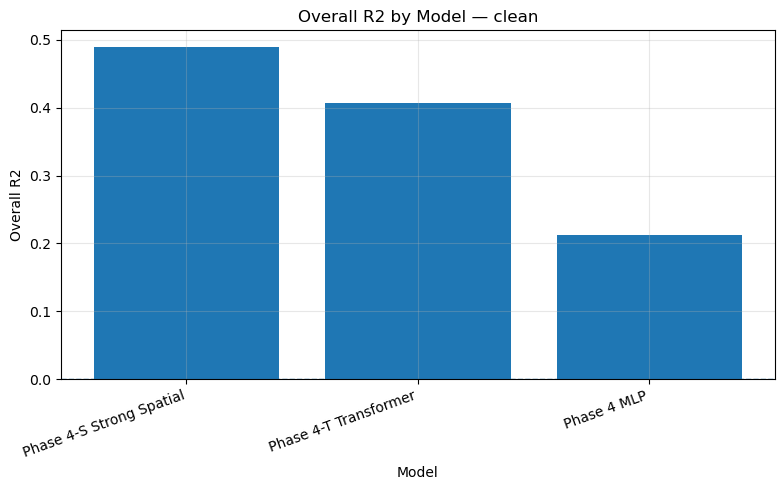

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/overall_r2_by_model_clean.png


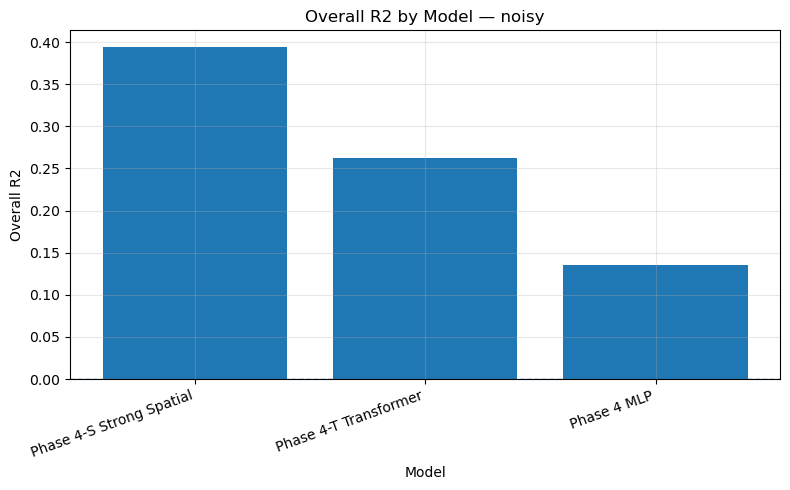

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/overall_r2_by_model_noisy.png


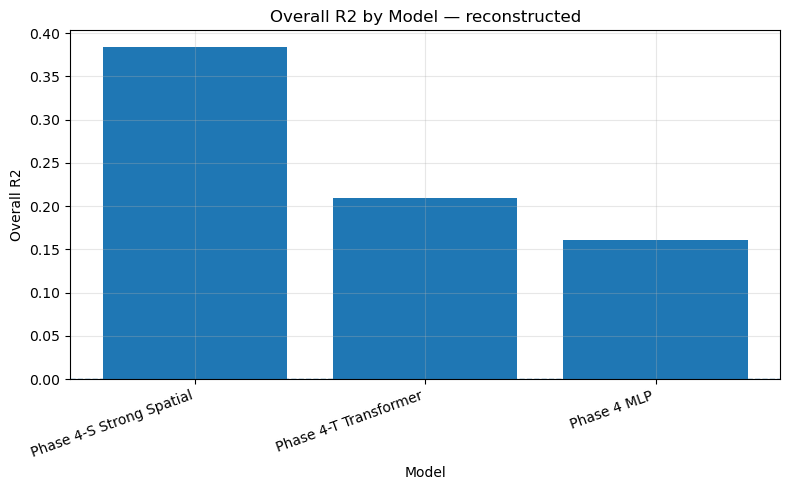

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/overall_r2_by_model_reconstructed.png


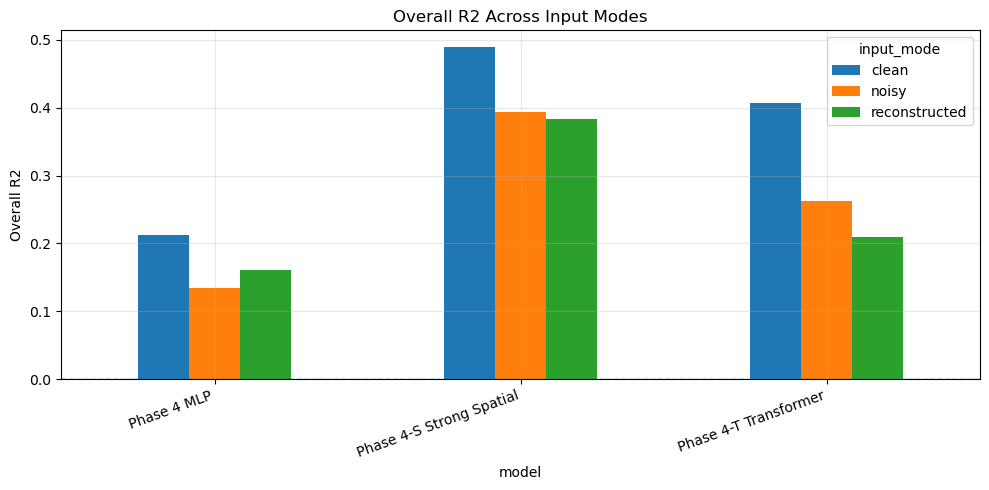

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/overall_r2_all_models_all_modes.png


In [8]:
# ================================================================
# 8. Overall R2 comparison plots
# ================================================================

if len(overall_df):
    plot_df = overall_df.copy()

    for mode in INPUT_MODES:
        mode_df = plot_df[plot_df["input_mode"] == mode].copy()
        if len(mode_df) == 0:
            continue

        mode_df = mode_df.sort_values("overall_r2", ascending=False)

        plt.figure(figsize=(8, 5))
        plt.bar(mode_df["model"].astype(str).to_numpy(), mode_df["overall_r2"].to_numpy())
        plt.axhline(0.0, linestyle="--", linewidth=1)
        plt.xlabel("Model")
        plt.ylabel("Overall R2")
        plt.title(f"Overall R2 by Model — {mode}")
        plt.xticks(rotation=20, ha="right")
        plt.grid(alpha=0.3)
        plt.tight_layout()

        path = COMPARISON_DIR / f"overall_r2_by_model_{mode}.png"
        plt.savefig(path, dpi=150)
        plt.show()
        print("Saved:", path)

    pivot_overall = overall_df.pivot_table(
        index="model",
        columns="input_mode",
        values="overall_r2",
        aggfunc="first",
    ).reindex(columns=INPUT_MODES)

    ax = pivot_overall.plot(kind="bar", figsize=(10, 5))
    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_ylabel("Overall R2")
    ax.set_title("Overall R2 Across Input Modes")
    ax.grid(alpha=0.3)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    path = COMPARISON_DIR / "overall_r2_all_models_all_modes.png"
    plt.savefig(path, dpi=150)
    plt.show()
    print("Saved:", path)

/tmp/ipykernel_16606/663414646.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = mode_df.pivot_table(


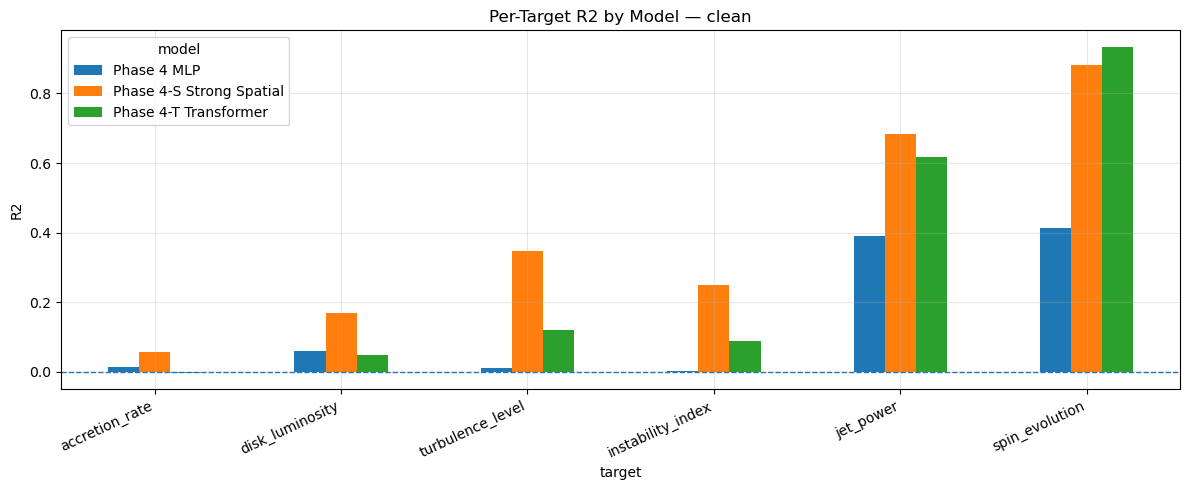

/tmp/ipykernel_16606/663414646.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = mode_df.pivot_table(


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/per_target_r2_by_model_clean.png


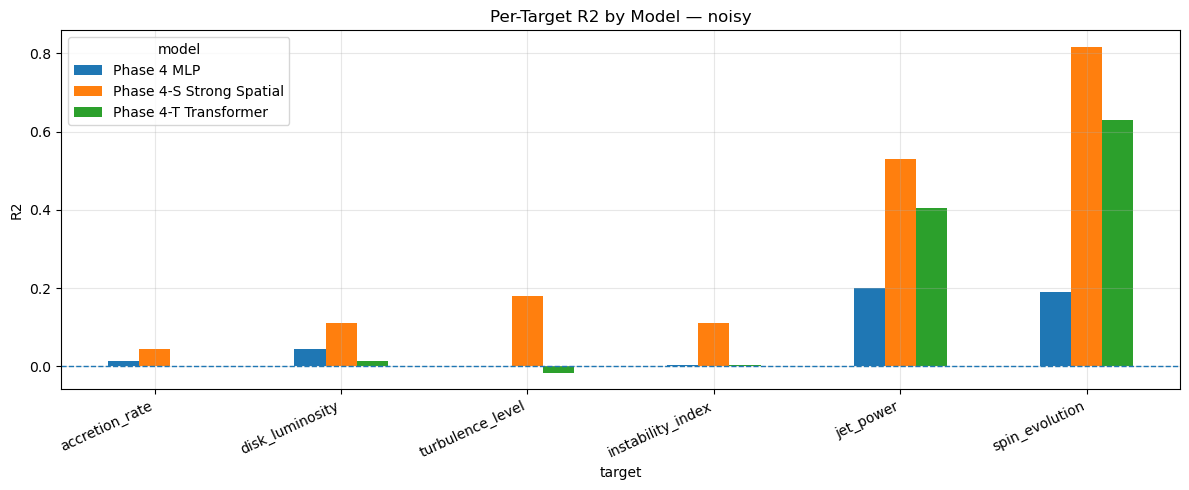

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/per_target_r2_by_model_noisy.png


/tmp/ipykernel_16606/663414646.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = mode_df.pivot_table(


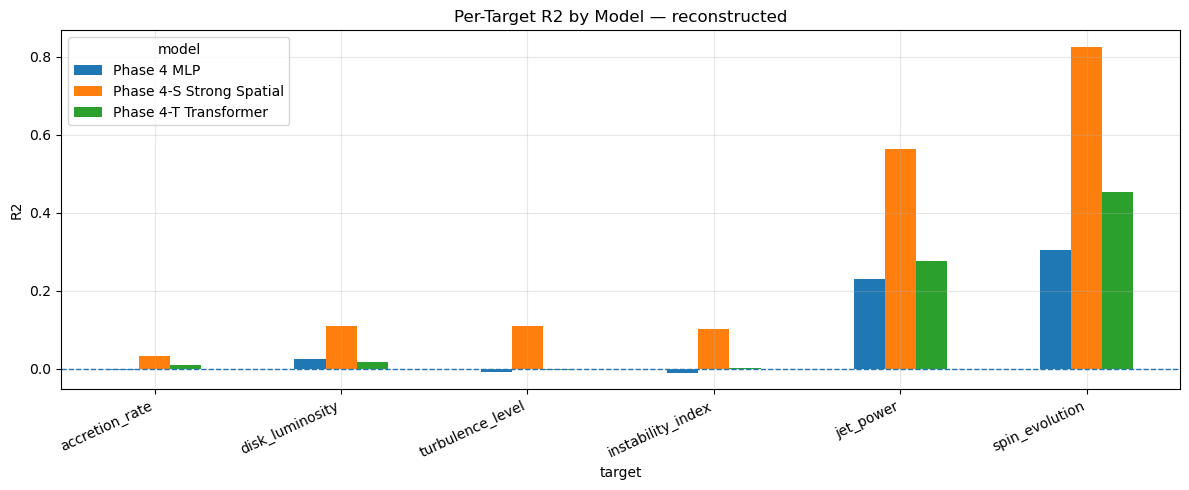

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/per_target_r2_by_model_reconstructed.png


/tmp/ipykernel_16606/663414646.py:34: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = model_df.pivot_table(


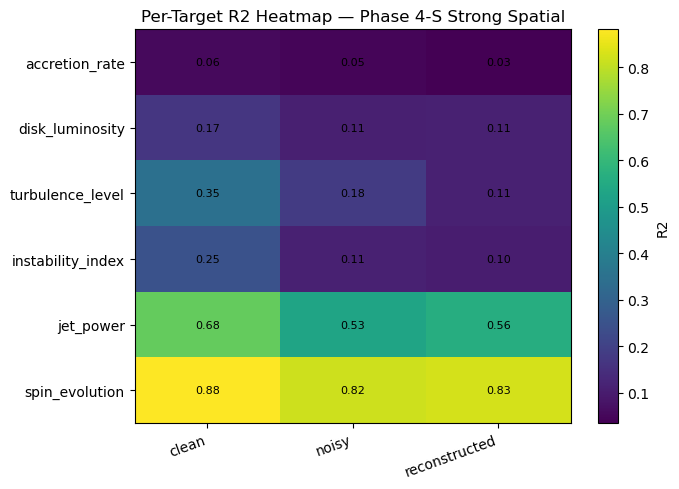

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/r2_heatmap_phase_4s_strong_spatial.png


/tmp/ipykernel_16606/663414646.py:34: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = model_df.pivot_table(


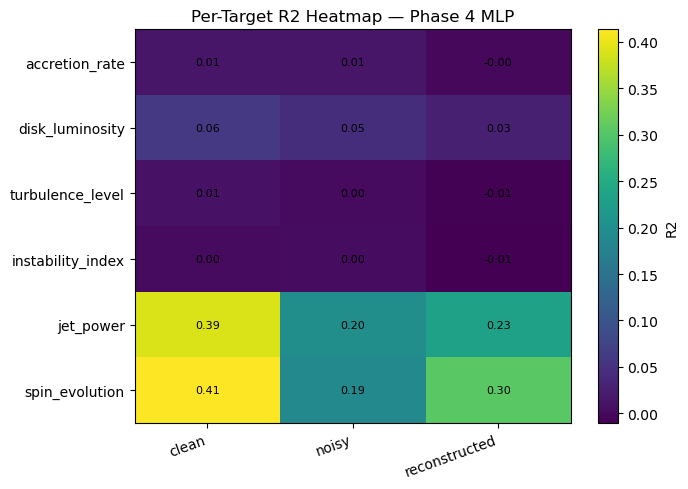

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/r2_heatmap_phase_4_mlp.png


/tmp/ipykernel_16606/663414646.py:34: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = model_df.pivot_table(


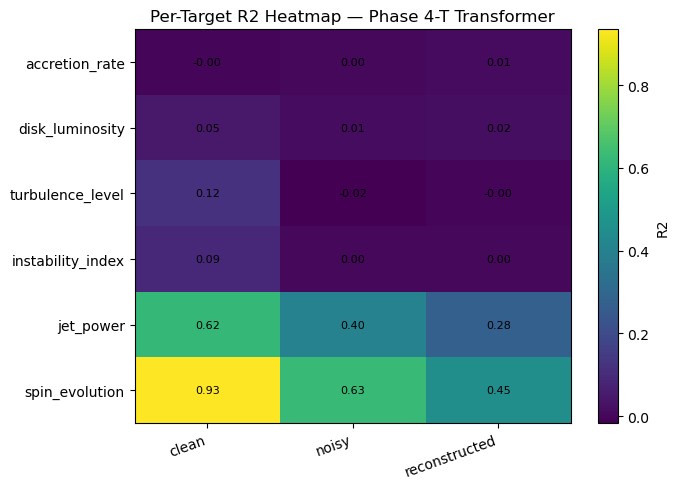

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/r2_heatmap_phase_4t_transformer.png


In [9]:
# ================================================================
# 9. Per-target R2 comparison plots
# ================================================================

if len(per_target_all_df):
    for mode in INPUT_MODES:
        mode_df = per_target_all_df[per_target_all_df["input_mode"] == mode].copy()
        if len(mode_df) == 0:
            continue

        pivot = mode_df.pivot_table(
            index="target",
            columns="model",
            values="r2",
            aggfunc="first",
        ).reindex(TARGET_COLUMNS)

        ax = pivot.plot(kind="bar", figsize=(12, 5))
        ax.axhline(0.0, linestyle="--", linewidth=1)
        ax.set_ylabel("R2")
        ax.set_title(f"Per-Target R2 by Model — {mode}")
        ax.grid(alpha=0.3)
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()

        path = COMPARISON_DIR / f"per_target_r2_by_model_{mode}.png"
        plt.savefig(path, dpi=150)
        plt.show()
        print("Saved:", path)

    # Heatmap-style plot using plain matplotlib, one per model.
    for model_name in per_target_all_df["model"].dropna().unique():
        model_df = per_target_all_df[per_target_all_df["model"] == model_name].copy()
        pivot = model_df.pivot_table(
            index="target",
            columns="input_mode",
            values="r2",
            aggfunc="first",
        ).reindex(TARGET_COLUMNS).reindex(columns=INPUT_MODES)

        data = pivot.to_numpy(dtype=float)

        plt.figure(figsize=(7, 5))
        im = plt.imshow(data, aspect="auto")
        plt.colorbar(im, label="R2")
        plt.xticks(np.arange(len(INPUT_MODES)), INPUT_MODES, rotation=20, ha="right")
        plt.yticks(np.arange(len(TARGET_COLUMNS)), TARGET_COLUMNS)
        plt.title(f"Per-Target R2 Heatmap — {model_name}")

        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                value = data[i, j]
                if np.isfinite(value):
                    plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

        plt.tight_layout()
        safe_name = str(model_name).lower().replace(" ", "_").replace("-", "").replace("/", "_")
        path = COMPARISON_DIR / f"r2_heatmap_{safe_name}.png"
        plt.savefig(path, dpi=150)
        plt.show()
        print("Saved:", path)

In [10]:
# ================================================================
# 10. Best model per target and input mode
# ================================================================

best_rows = []

if len(per_target_all_df):
    for mode in INPUT_MODES:
        mode_df = per_target_all_df[per_target_all_df["input_mode"] == mode].copy()
        for target in TARGET_COLUMNS:
            target_df = mode_df[mode_df["target"].astype(str) == target].copy()
            target_df = target_df.dropna(subset=["r2"])
            if len(target_df) == 0:
                continue
            best = target_df.sort_values("r2", ascending=False).iloc[0]
            best_rows.append({
                "input_mode": mode,
                "target": target,
                "best_model": best["model"],
                "best_r2": float(best["r2"]),
                "best_corr": float(best["corr"]),
                "best_mae": float(best["mae"]),
                "best_recoverability": best["recoverability"],
            })

best_model_df = pd.DataFrame(best_rows)
best_model_path = COMPARISON_DIR / "best_model_per_target_and_mode.csv"
best_model_df.to_csv(best_model_path, index=False)

display(best_model_df)
print("Saved:", best_model_path)

# Count how often each model wins.
if len(best_model_df):
    win_counts = (
        best_model_df.groupby("best_model")
        .size()
        .reset_index(name="num_target_mode_wins")
        .sort_values("num_target_mode_wins", ascending=False)
    )
    win_counts_path = COMPARISON_DIR / "model_win_counts.csv"
    win_counts.to_csv(win_counts_path, index=False)

    display(win_counts)
    print("Saved:", win_counts_path)

,input_mode,target,best_model,best_r2,best_corr,best_mae,best_recoverability
0,clean,accretion_rate,Phase 4-S Strong Spatial,0.056712,0.264519,0.153387,weak
1,clean,disk_luminosity,Phase 4-S Strong Spatial,0.167938,0.424098,0.115401,weak
2,clean,turbulence_level,Phase 4-S Strong Spatial,0.347873,0.595258,0.156576,moderate
3,clean,instability_index,Phase 4-S Strong Spatial,0.248135,0.499267,0.191345,weak
4,clean,jet_power,Phase 4-S Strong Spatial,0.682174,0.826782,0.071915,strong
5,clean,spin_evolution,Phase 4-T Transformer,0.934600,0.969277,0.058154,strong
6,noisy,accretion_rate,Phase 4-S Strong Spatial,0.045482,0.269116,0.154272,marginal
7,noisy,disk_luminosity,Phase 4-S Strong Spatial,0.109557,0.392050,0.118423,weak
8,noisy,turbulence_level,Phase 4-S Strong Spatial,0.180377,0.439770,0.182384,weak
9,noisy,instability_index,Phase 4-S Strong Spatial,0.111224,0.338937,0.212524,weak


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/best_model_per_target_and_mode.csv


,best_model,num_target_mode_wins
0,Phase 4-S Strong Spatial,17
1,Phase 4-T Transformer,1


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/model_win_counts.csv


,input_mode,target,mlp_r2,transformer_r2,strong_spatial_r2,transformer_minus_mlp,strong_minus_mlp,strong_minus_transformer
0,clean,accretion_rate,0.014734,-0.004039,0.056712,-0.018773,0.041978,0.060751
1,clean,disk_luminosity,0.059230,0.046775,0.167938,-0.012456,0.108708,0.121163
2,clean,turbulence_level,0.010534,0.120350,0.347873,0.109815,0.337338,0.227523
3,clean,instability_index,0.002351,0.089121,0.248135,0.086769,0.245783,0.159014
4,clean,jet_power,0.389178,0.617466,0.682174,0.228289,0.292996,0.064707
5,clean,spin_evolution,0.413497,0.934600,0.881378,0.521103,0.467881,-0.053222
6,noisy,accretion_rate,0.014511,0.001577,0.045482,-0.012934,0.030971,0.043905
7,noisy,disk_luminosity,0.045133,0.012819,0.109557,-0.032313,0.064425,0.096738
8,noisy,turbulence_level,0.002090,-0.017097,0.180377,-0.019187,0.178287,0.197474
9,noisy,instability_index,0.004138,0.003058,0.111224,-0.001081,0.107086,0.108167


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/capacity_gain_analysis.csv


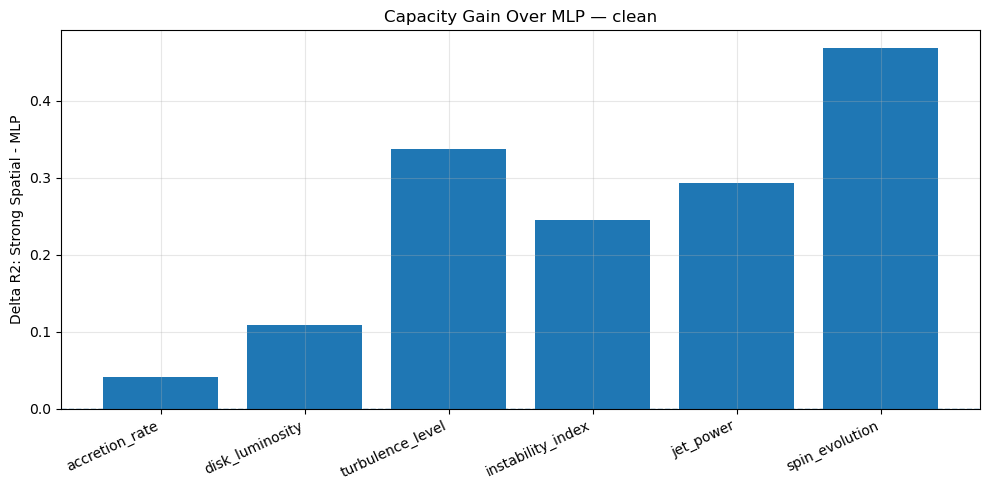

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/strong_spatial_gain_over_mlp_clean.png


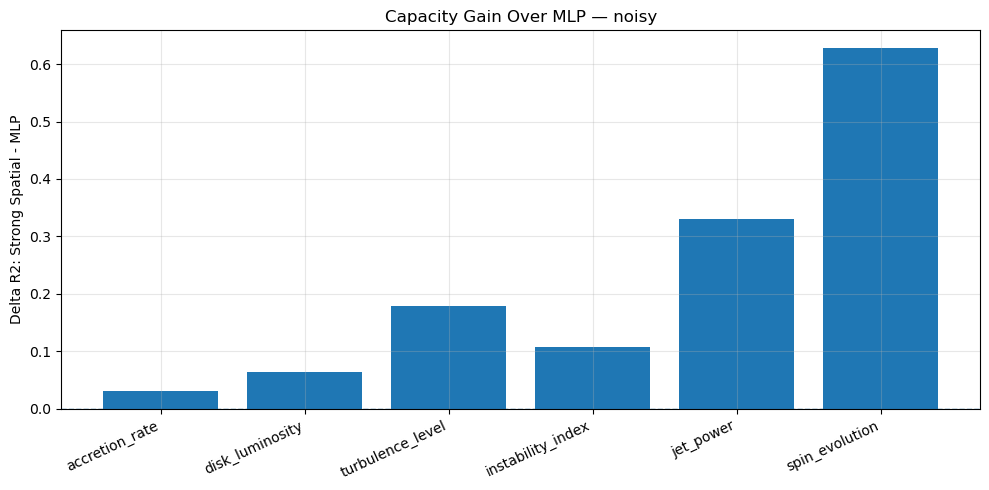

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/strong_spatial_gain_over_mlp_noisy.png


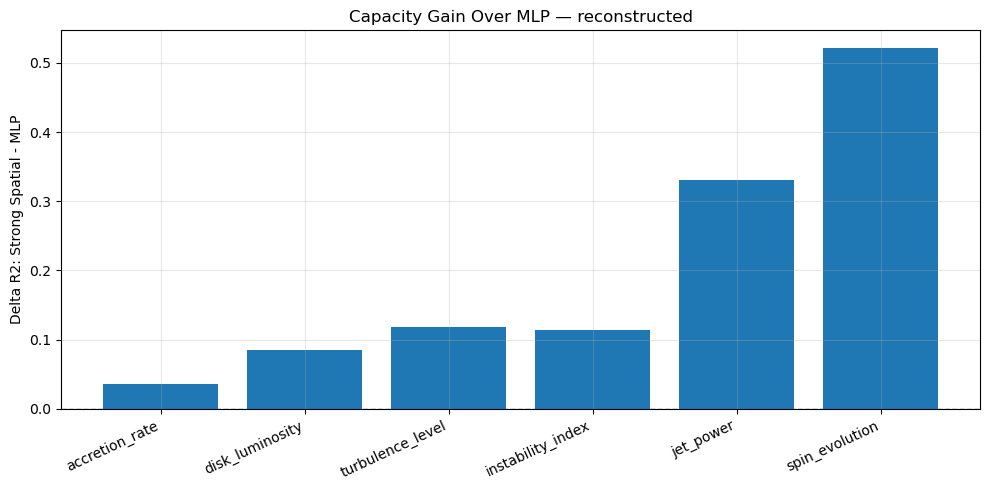

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/strong_spatial_gain_over_mlp_reconstructed.png


In [11]:
# ================================================================
# 11. Capacity gain analysis
# ================================================================
# This directly tests whether stronger spatial models improved recovery
# over the pooled MLP baseline and the transformer ablation.

capacity_rows = []

if len(per_target_all_df):
    for mode in INPUT_MODES:
        for target in TARGET_COLUMNS:
            subset = per_target_all_df[
                (per_target_all_df["input_mode"] == mode)
                & (per_target_all_df["target"].astype(str) == target)
            ].copy()

            def r2_for(model_key):
                rows = subset[subset["model_key"] == model_key]
                if len(rows) == 0:
                    return np.nan
                return float(rows.iloc[0]["r2"])

            mlp_r2 = r2_for("mlp")
            transformer_r2 = r2_for("transformer")
            strong_r2 = r2_for("strong_spatial")

            capacity_rows.append({
                "input_mode": mode,
                "target": target,
                "mlp_r2": mlp_r2,
                "transformer_r2": transformer_r2,
                "strong_spatial_r2": strong_r2,
                "transformer_minus_mlp": transformer_r2 - mlp_r2 if np.isfinite(transformer_r2) and np.isfinite(mlp_r2) else np.nan,
                "strong_minus_mlp": strong_r2 - mlp_r2 if np.isfinite(strong_r2) and np.isfinite(mlp_r2) else np.nan,
                "strong_minus_transformer": strong_r2 - transformer_r2 if np.isfinite(strong_r2) and np.isfinite(transformer_r2) else np.nan,
            })

capacity_df = pd.DataFrame(capacity_rows)
capacity_path = COMPARISON_DIR / "capacity_gain_analysis.csv"
capacity_df.to_csv(capacity_path, index=False)

display(capacity_df)
print("Saved:", capacity_path)

# Plot strong-spatial gain over MLP for each mode.
if len(capacity_df):
    for mode in INPUT_MODES:
        mode_df = capacity_df[capacity_df["input_mode"] == mode].copy()
        if len(mode_df) == 0 or mode_df["strong_minus_mlp"].isna().all():
            continue

        mode_df["target"] = pd.Categorical(mode_df["target"], categories=TARGET_COLUMNS, ordered=True)
        mode_df = mode_df.sort_values("target")

        plt.figure(figsize=(10, 5))
        plt.bar(mode_df["target"].astype(str).to_numpy(), mode_df["strong_minus_mlp"].to_numpy())
        plt.axhline(0.0, linestyle="--", linewidth=1)
        plt.ylabel("Delta R2: Strong Spatial - MLP")
        plt.title(f"Capacity Gain Over MLP — {mode}")
        plt.xticks(rotation=25, ha="right")
        plt.grid(alpha=0.3)
        plt.tight_layout()

        path = COMPARISON_DIR / f"strong_spatial_gain_over_mlp_{mode}.png"
        plt.savefig(path, dpi=150)
        plt.show()
        print("Saved:", path)

In [12]:
# ================================================================
# 12. Input degradation analysis
# ================================================================
# Compares clean -> noisy and clean -> reconstructed for each model.

input_degradation_rows = []

if len(per_target_all_df):
    for model_key in per_target_all_df["model_key"].dropna().unique():
        model_df = per_target_all_df[per_target_all_df["model_key"] == model_key].copy()
        model_name = model_df["model"].iloc[0]

        for target in TARGET_COLUMNS:
            rows = model_df[model_df["target"].astype(str) == target]

            def mode_r2(mode):
                r = rows[rows["input_mode"] == mode]
                if len(r) == 0:
                    return np.nan
                return float(r.iloc[0]["r2"])

            clean_r2 = mode_r2("clean")
            noisy_r2 = mode_r2("noisy")
            reconstructed_r2 = mode_r2("reconstructed")

            input_degradation_rows.append({
                "model_key": model_key,
                "model": model_name,
                "target": target,
                "clean_r2": clean_r2,
                "noisy_r2": noisy_r2,
                "reconstructed_r2": reconstructed_r2,
                "noisy_minus_clean": noisy_r2 - clean_r2 if np.isfinite(noisy_r2) and np.isfinite(clean_r2) else np.nan,
                "reconstructed_minus_clean": reconstructed_r2 - clean_r2 if np.isfinite(reconstructed_r2) and np.isfinite(clean_r2) else np.nan,
                "reconstructed_minus_noisy": reconstructed_r2 - noisy_r2 if np.isfinite(reconstructed_r2) and np.isfinite(noisy_r2) else np.nan,
            })

input_degradation_df = pd.DataFrame(input_degradation_rows)
input_degradation_path = COMPARISON_DIR / "input_mode_degradation_by_model_and_target.csv"
input_degradation_df.to_csv(input_degradation_path, index=False)

display(input_degradation_df)
print("Saved:", input_degradation_path)

,model_key,model,target,clean_r2,noisy_r2,reconstructed_r2,noisy_minus_clean,reconstructed_minus_clean,reconstructed_minus_noisy
0,strong_spatial,Phase 4-S Strong Spatial,accretion_rate,0.056712,0.045482,0.034353,-0.011230,-0.022359,-0.011129
1,strong_spatial,Phase 4-S Strong Spatial,disk_luminosity,0.167938,0.109557,0.111135,-0.058381,-0.056804,0.001577
2,strong_spatial,Phase 4-S Strong Spatial,turbulence_level,0.347873,0.180377,0.110716,-0.167496,-0.237157,-0.069661
3,strong_spatial,Phase 4-S Strong Spatial,instability_index,0.248135,0.111224,0.103149,-0.136910,-0.144986,-0.008075
4,strong_spatial,Phase 4-S Strong Spatial,jet_power,0.682174,0.529112,0.562363,-0.153062,-0.119810,0.033252
5,strong_spatial,Phase 4-S Strong Spatial,spin_evolution,0.881378,0.816982,0.825791,-0.064396,-0.055587,0.008809
6,mlp,Phase 4 MLP,accretion_rate,0.014734,0.014511,-0.001565,-0.000223,-0.016299,-0.016077
7,mlp,Phase 4 MLP,disk_luminosity,0.059230,0.045133,0.026233,-0.014098,-0.032998,-0.018900
8,mlp,Phase 4 MLP,turbulence_level,0.010534,0.002090,-0.008227,-0.008445,-0.018762,-0.010317
9,mlp,Phase 4 MLP,instability_index,0.002351,0.004138,-0.010519,0.001787,-0.012870,-0.014657


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/input_mode_degradation_by_model_and_target.csv


In [13]:
# ================================================================
# 13. Thesis-ready final interpretation
# ================================================================

def safe_float(x):
    try:
        if np.isfinite(float(x)):
            return float(x)
    except Exception:
        pass
    return np.nan

best_overall = None
if len(overall_df):
    best_overall = overall_df.dropna(subset=["overall_r2"]).sort_values("overall_r2", ascending=False).iloc[0]

best_target_overall = None
if len(per_target_all_df):
    best_target_overall = per_target_all_df.dropna(subset=["r2"]).sort_values("r2", ascending=False).iloc[0]

# Strong-spatial reconstructed result is often the most practically relevant because it includes the full observation -> reconstruction -> memory path.
strong_recon = overall_df[
    (overall_df["model_key"] == "strong_spatial")
    & (overall_df["input_mode"] == "reconstructed")
].copy()

summary_lines = []
summary_lines.append("Phase 4 Model Comparison — Final Synthesis")
summary_lines.append("=" * 52)
summary_lines.append("")
summary_lines.append(f"Dataset: {DATASET_DIR}")
summary_lines.append(f"Comparison output directory: {COMPARISON_DIR}")
summary_lines.append("")

summary_lines.append("Loaded model families:")
for name, path in resolved_dirs.items():
    status = str(path) if path is not None else "missing"
    summary_lines.append(f"  - {name}: {status}")
summary_lines.append("")

if best_overall is not None:
    summary_lines.append("Best overall run:")
    summary_lines.append(f"  Model      : {best_overall['model']}")
    summary_lines.append(f"  Input mode : {best_overall['input_mode']}")
    summary_lines.append(f"  MAE        : {best_overall['overall_mae']:.5f}")
    summary_lines.append(f"  Corr       : {best_overall['overall_corr']:.5f}")
    summary_lines.append(f"  R2         : {best_overall['overall_r2']:.5f}")
    summary_lines.append("")

if best_target_overall is not None:
    summary_lines.append("Most recoverable target across all loaded runs:")
    summary_lines.append(f"  Target     : {best_target_overall['target']}")
    summary_lines.append(f"  Model      : {best_target_overall['model']}")
    summary_lines.append(f"  Input mode : {best_target_overall['input_mode']}")
    summary_lines.append(f"  Corr       : {best_target_overall['corr']:.5f}")
    summary_lines.append(f"  R2         : {best_target_overall['r2']:.5f}")
    summary_lines.append(f"  Class      : {best_target_overall['recoverability']}")
    summary_lines.append("")

if len(strong_recon):
    row = strong_recon.iloc[0]
    summary_lines.append("Most practical end-to-end strong-spatial result:")
    summary_lines.append("  Model      : Phase 4-S Strong Spatial")
    summary_lines.append("  Input mode : reconstructed")
    summary_lines.append(f"  MAE        : {row['overall_mae']:.5f}")
    summary_lines.append(f"  Corr       : {row['overall_corr']:.5f}")
    summary_lines.append(f"  R2         : {row['overall_r2']:.5f}")
    summary_lines.append("")

summary_lines.append("Core interpretation:")
summary_lines.append("  The comparison tests whether failures in earlier memory-reconstruction phases came from")
summary_lines.append("  predictor capacity or from image-level identifiability limits. If Phase 4-S improves a")
summary_lines.append("  target substantially over MLP and Transformer baselines, the older predictors were not")
summary_lines.append("  extracting spatial morphology effectively. If a target remains weak even under Phase 4-S,")
summary_lines.append("  the more defensible interpretation is weak identifiability from a single current image.")
summary_lines.append("")

if len(capacity_df):
    summary_lines.append("Targets with strongest capacity gain from Strong Spatial over MLP:")
    gain_df = capacity_df.dropna(subset=["strong_minus_mlp"]).sort_values("strong_minus_mlp", ascending=False).head(8)
    for _, row in gain_df.iterrows():
        summary_lines.append(
            f"  - {row['target']} ({row['input_mode']}): delta R2 = {row['strong_minus_mlp']:.5f}"
        )
    summary_lines.append("")

summary_lines.append("Decision:")
summary_lines.append("  Use this comparison as the final model-capacity audit. Do not keep generating new dataset")
summary_lines.append("  phases unless the comparison shows that even clean strong-spatial predictions are bottlenecked")
summary_lines.append("  by a specific missing visual signature. The thesis should report partial recoverability rather")
summary_lines.append("  than claiming full historical recovery from one static observation.")

summary_text = "\n".join(summary_lines)
summary_path = COMPARISON_DIR / "phase4_model_comparison_final_summary.txt"
with open(summary_path, "w") as f:
    f.write(summary_text)

print(summary_text)
print("\nSaved:", summary_path)

Phase 4 Model Comparison — Final Synthesis

Dataset: /home/marwa/files/phase1_blackhole_generator/data/dataset_phase5_8_morphology
Comparison output directory: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final

Loaded model families:
  - Phase 4 MLP: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_multi_channel_memory_prediction_phase58
  - Phase 4-T Transformer: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_transformer_memory_prediction_phase58
  - Phase 4-S Strong Spatial: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_s_strong_spatial_memory_predictor

Best overall run:
  Model      : Phase 4-S Strong Spatial
  Input mode : clean
  MAE        : 0.12560
  Corr       : 0.70162
  R2         : 0.48969

Most recoverable target across all loaded runs:
  Target     : spin_evolution
  Model      : Phase 4-T Transformer
  Input mode : clean
  Corr       : 0.96928
  R2         : 0.93460
  Class      : strong

Most practic

In [14]:
# ================================================================
# 14. Export compact thesis tables
# ================================================================

# Compact overall R2 table.
if len(overall_df):
    compact_overall = overall_df.pivot_table(
        index="model",
        columns="input_mode",
        values="overall_r2",
        aggfunc="first",
    ).reindex(columns=INPUT_MODES)
    compact_overall_path = COMPARISON_DIR / "compact_overall_r2_table.csv"
    compact_overall.to_csv(compact_overall_path)
    display(compact_overall)
    print("Saved:", compact_overall_path)

# Compact per-target R2 table for strong-spatial model.
if len(per_target_all_df):
    strong_df = per_target_all_df[per_target_all_df["model_key"] == "strong_spatial"].copy()
    if len(strong_df):
        compact_strong = strong_df.pivot_table(
            index="target",
            columns="input_mode",
            values="r2",
            aggfunc="first",
        ).reindex(TARGET_COLUMNS).reindex(columns=INPUT_MODES)
        compact_strong_path = COMPARISON_DIR / "compact_strong_spatial_per_target_r2_table.csv"
        compact_strong.to_csv(compact_strong_path)
        display(compact_strong)
        print("Saved:", compact_strong_path)

# Compact winner table.
if len(best_model_df):
    winner_pivot = best_model_df.pivot_table(
        index="target",
        columns="input_mode",
        values="best_model",
        aggfunc="first",
    ).reindex(TARGET_COLUMNS).reindex(columns=INPUT_MODES)
    winner_path = COMPARISON_DIR / "compact_best_model_winner_table.csv"
    winner_pivot.to_csv(winner_path)
    display(winner_pivot)
    print("Saved:", winner_path)

input_mode,clean,noisy,reconstructed
model,,,
Phase 4 MLP,0.212573,0.134942,0.160268
Phase 4-S Strong Spatial,0.489687,0.394160,0.383980
Phase 4-T Transformer,0.407181,0.262474,0.208946


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/compact_overall_r2_table.csv


/tmp/ipykernel_16606/2257528325.py:22: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  compact_strong = strong_df.pivot_table(


input_mode,clean,noisy,reconstructed
target,,,
accretion_rate,0.056712,0.045482,0.034353
disk_luminosity,0.167938,0.109557,0.111135
turbulence_level,0.347873,0.180377,0.110716
instability_index,0.248135,0.111224,0.103149
jet_power,0.682174,0.529112,0.562363
spin_evolution,0.881378,0.816982,0.825791


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/compact_strong_spatial_per_target_r2_table.csv


input_mode,clean,noisy,reconstructed
target,,,
accretion_rate,Phase 4-S Strong Spatial,Phase 4-S Strong Spatial,Phase 4-S Strong Spatial
disk_luminosity,Phase 4-S Strong Spatial,Phase 4-S Strong Spatial,Phase 4-S Strong Spatial
turbulence_level,Phase 4-S Strong Spatial,Phase 4-S Strong Spatial,Phase 4-S Strong Spatial
instability_index,Phase 4-S Strong Spatial,Phase 4-S Strong Spatial,Phase 4-S Strong Spatial
jet_power,Phase 4-S Strong Spatial,Phase 4-S Strong Spatial,Phase 4-S Strong Spatial
spin_evolution,Phase 4-T Transformer,Phase 4-S Strong Spatial,Phase 4-S Strong Spatial


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_model_comparison_final/compact_best_model_winner_table.csv


## How to use this notebook

Run the notebook once. It will automatically load whichever of these result folders exist:

- `outputs/phase4_multi_channel_memory_prediction_phase58`
- `outputs/phase4_transformer_memory_prediction_phase58`
- `outputs/phase4_s_strong_spatial_memory_predictor`

The key files saved by this notebook are:

- `overall_model_comparison.csv`
- `per_target_model_comparison_all.csv`
- `capacity_gain_analysis.csv`
- `input_mode_degradation_by_model_and_target.csv`
- `phase4_model_comparison_final_summary.txt`

Use those files directly in your final audit/synthesis section.